In [4]:
import os
print(os.getcwd())

C:\Users\priya


In [5]:
import os
print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.cache', '.conda', '.continuum', '.eclipse', '.idlerc', '.ipynb_checkpoints', '.ipython', '.java', '.jupyter', '.matplotlib', '.ms-ad', '.nbi', '.node_repl_history', '.p2', '.pipwin', '.redhat', '.thumbnails', '.tooling', '.vscode', '.vscode-cli', 'anaconda3', 'AppData', 'Application Data', 'attendence.java', 'c program', 'Contacts', 'Cookies', 'Creative Cloud Files  priya03awasthi@gmail.com 5F587BDF62D2A9DE0A495EA6@AdobeID', 'Desktop', 'desktop.ini', 'dictonary.ipynb', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'Favorites', 'firstClass.java', 'heelo world.java', 'ibisPaint', 'IBM Python Day-1 (1).ipynb', 'if else .zava.java', 'ifelse.java', 'is.java', 'java', 'Links', 'Local Settings', 'Microsoft', 'Muse Hub', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001

In [7]:
import pandas as pd

df = pd.read_csv("USvideos.csv", encoding="latin-1")
print(df.shape)
print(df.head())

PermissionError: [Errno 13] Permission denied: 'USvideos.csv'

In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\priya\USvideos.csv", encoding="latin-1")
print(df.shape)
print(df.head())

(40949, 16)
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                                tags   

In [9]:
print(df.columns.tolist())
print("\n")
print(df.dtypes)
print("\n")
print(df.isnull().sum())


['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']


video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object


video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
vi

In [10]:
import json

with open(r"C:\Users\priya\US_category_id.json", encoding="utf-8") as f:
    categories = json.load(f)

cat_dict = {int(item["id"]): item["snippet"]["title"] for item in categories["items"]}

df["category"] = df["category_id"].map(cat_dict)

print(df["category"].value_counts())

category
Entertainment            9964
Music                    6472
Howto & Style            4146
Comedy                   3457
People & Blogs           3210
News & Politics          2487
Science & Technology     2401
Film & Animation         2345
Sports                   2174
Education                1656
Pets & Animals            920
Gaming                    817
Travel & Events           402
Autos & Vehicles          384
Nonprofits & Activism      57
Shows                      57
Name: count, dtype: int64


C:\Users\priya\AppData\Local\Temp\ipykernel_3532\2033165690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_views.values, y=category_views.index, palette="Greys_r")


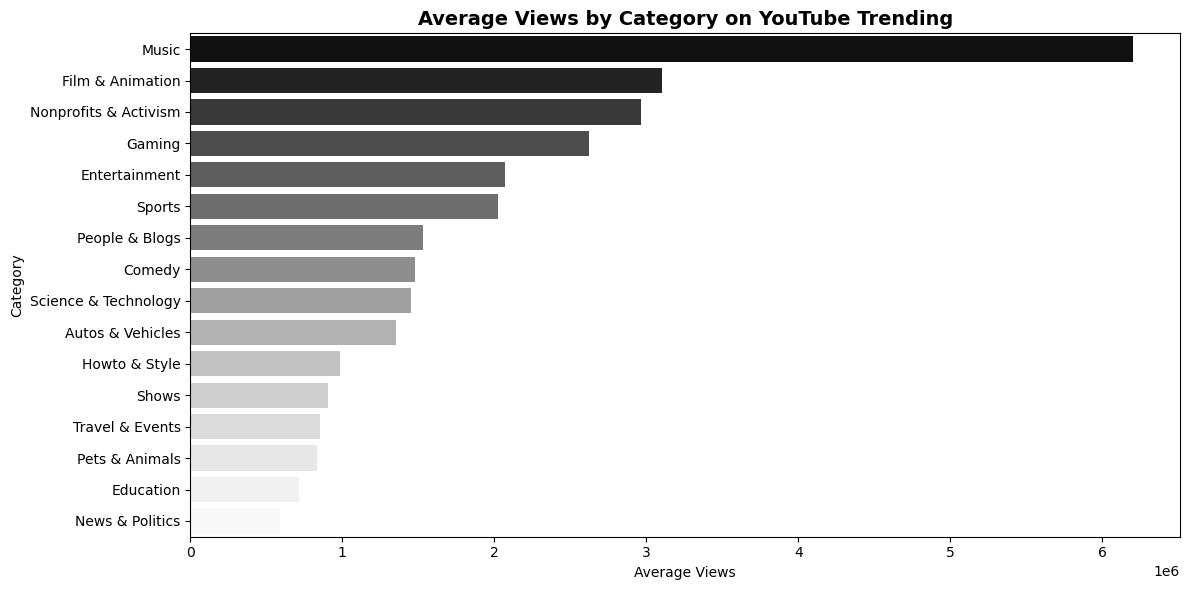

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

category_views = df.groupby("category")["views"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_views.values, y=category_views.index, palette="Greys_r")
plt.title("Average Views by Category on YouTube Trending", fontsize=14, fontweight="bold")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("chart1_avg_views_by_category.png", dpi=150)
plt.show()

C:\Users\priya\AppData\Local\Temp\ipykernel_3532\332845682.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_views.index, y=day_views.values, palette="Greys_r")


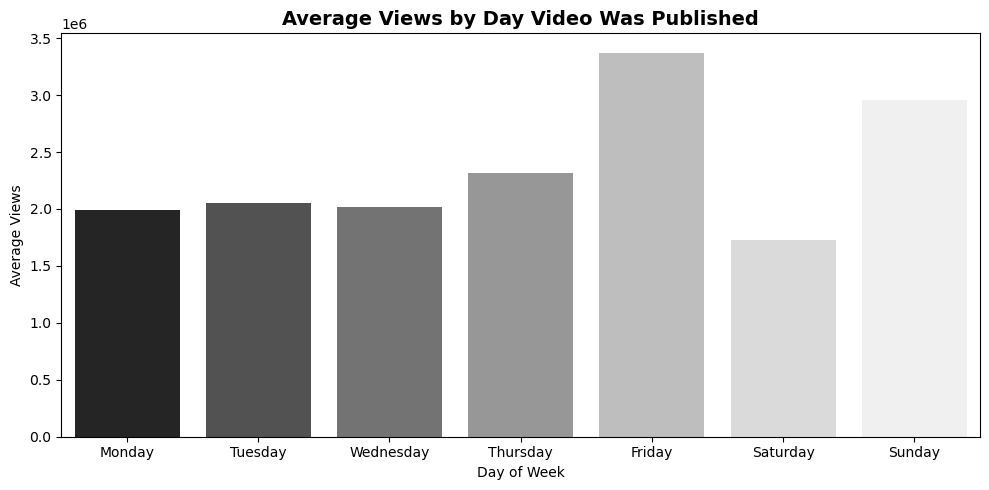

In [12]:
df["publish_day"] = pd.to_datetime(df["publish_time"]).dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_views = df.groupby("publish_day")["views"].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_views.index, y=day_views.values, palette="Greys_r")
plt.title("Average Views by Day Video Was Published", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Average Views")
plt.tight_layout()
plt.savefig("chart2_views_by_publish_day.png", dpi=150)
plt.show()

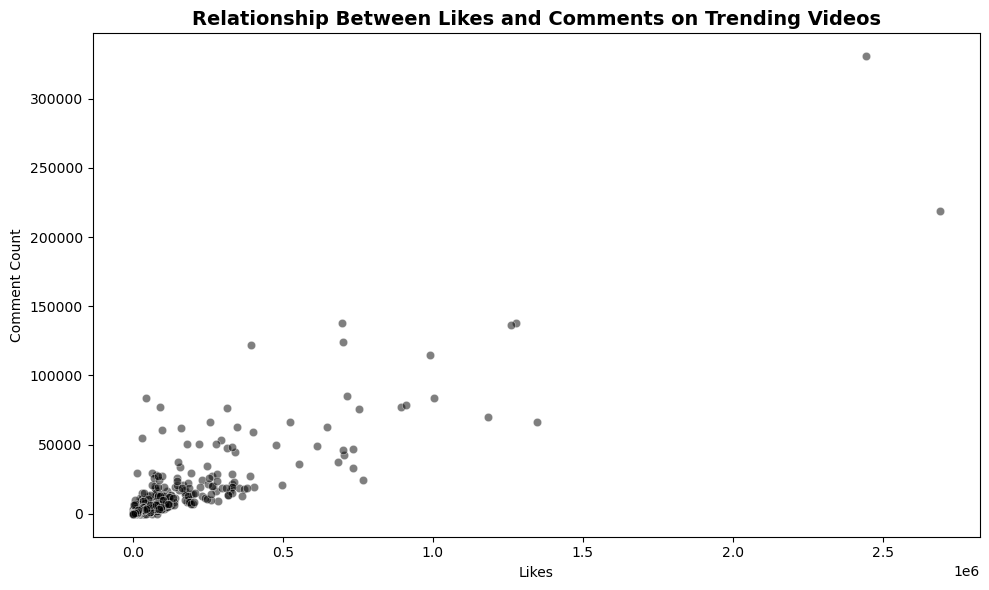

In [13]:
sample = df.sample(1000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(x="likes", y="comment_count", data=sample, alpha=0.5, color="black")
plt.title("Relationship Between Likes and Comments on Trending Videos", fontsize=14, fontweight="bold")
plt.xlabel("Likes")
plt.ylabel("Comment Count")
plt.tight_layout()
plt.savefig("chart3_likes_vs_comments.png", dpi=150)
plt.show()

In [14]:
print("""
YOUTUBE TRENDING VIDEO ANALYSIS — KEY INSIGHTS
===============================================

Dataset: 40,949 US YouTube trending videos

1. CATEGORY REACH
   Music has the highest average views per video despite Entertainment
   having the most trending videos (9,964). Volume ≠ reach.

2. PUBLISH TIMING
   Videos published on Friday generate the highest average views,
   suggesting weekend viewing behaviour drives early momentum.

3. ENGAGEMENT PATTERN
   Strong positive correlation between likes and comment count —
   engagement metrics move together, not independently.

RECOMMENDATION: Creators and brands targeting maximum reach should
focus on Music-adjacent content published on Fridays.
""")


YOUTUBE TRENDING VIDEO ANALYSIS — KEY INSIGHTS

Dataset: 40,949 US YouTube trending videos

1. CATEGORY REACH
   Music has the highest average views per video despite Entertainment
   having the most trending videos (9,964). Volume ≠ reach.

2. PUBLISH TIMING
   Videos published on Friday generate the highest average views,
   suggesting weekend viewing behaviour drives early momentum.

3. ENGAGEMENT PATTERN
   Strong positive correlation between likes and comment count —
   engagement metrics move together, not independently.

RECOMMENDATION: Creators and brands targeting maximum reach should
focus on Music-adjacent content published on Fridays.

